# Neurons, Layers, and the Forward Pass

The DNN refresher: four chapters of neural-network fundamentals before the transformer
chapters assume them. This one builds the forward pass with plain NumPy:

1. **A single neuron** — a dot product, a bias, a squash
2. **Why nonlinearity** — stacked linear layers collapse to one
3. **XOR by hand** — the smallest problem a single neuron cannot solve
4. **Layers are matmuls** — the notation the whole book runs on

### Concepts covered

| # | Concept | What to watch for |
|---|---------|-------------------|
| 1 | Neuron | `w·x + b` defines a half-plane; the activation squashes it |
| 2 | Activation | Without one, depth buys nothing |
| 3 | Layer as matmul | `(batch, n_in) @ (n_in, n_out)` — shapes tell the story |
| 4 | Depth & width | Random deep nets already carve wiggly regions (universal approximation) |
| 5 | Decision boundary | What "the model's opinion of the plane" looks like |

Reference: [Cybenko (1989), universal approximation](https://doi.org/10.1007/BF02551274) · [docs/PAPERS.md](../../docs/PAPERS.md)

::: {.callout-tip title="📺 Video companion"}
[But what is a neural network? (3Blue1Brown)](https://www.youtube.com/watch?v=aircAruvnKk)
is the visual version of this chapter — more in [Videos](../../docs/VIDEOS.md).
:::

::: {.callout-note title="🎯 Goal — why this chapter, for the capstone"}
The book's project ([The Project](../../docs/PROJECT.md)) ends with **your own LLM served
through your own inference engine** — and that LLM is, at every layer, made of the objects
built here. The transformer FFN in `src/ai_playground/models/layers.py` is two of this
chapter's layers (with a multiplicative gate — SwiGLU); `dim` in your model's config is this
chapter's layer width; the logits your engine will sample from are one final `x @ W`.

This chapter is the vocabulary lesson: neuron, activation, layer, forward pass, decision
boundary. The refresher's own milestone (M0, chapter 03) and everything after it speaks
these words without stopping to define them.

🏗️ **Chapter milestone:** none — M0 lands in
[chapter 03](03_softmax_crossentropy.ipynb); this chapter builds the vocabulary for it.
:::

::: {.callout-tip title="⏱️ Session S0.1" appearance="simple"}
One one-hour session: read and run everything, then find the smallest MLP that still separates the moons.
Cards, prerequisites, and done-when tests: the [Session Guide](../../docs/SESSIONS.md).
:::

<a href="https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/00_dnn_refresher/00_neurons_and_mlps.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In [1]:
#| code-fold: true
#| code-summary: "Setup"
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

%config InlineBackend.figure_format = 'retina'
from ai_playground.plotting import apply_plot_style
apply_plot_style()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. A single neuron

A neuron computes `w · x + b` — a weighted vote over its inputs plus an offset — and passes
the result through a nonlinearity. That's it. With 2 inputs, `w · x + b = 0` is a *line*;
the neuron's output says how far on which side a point falls.

In [3]:
w = np.array([1.5, -1.0])   # weights: one per input
b = 0.5                     # bias: shifts the line off the origin

def neuron(x, activation=np.tanh):
    return activation(x @ w + b)

x = np.array([1.0, 2.0])
print(f'pre-activation  w·x + b = {x @ w + b:+.2f}')
print(f'after tanh              = {neuron(x):+.2f}')

pre-activation  w·x + b = +0.00
after tanh              = +0.00


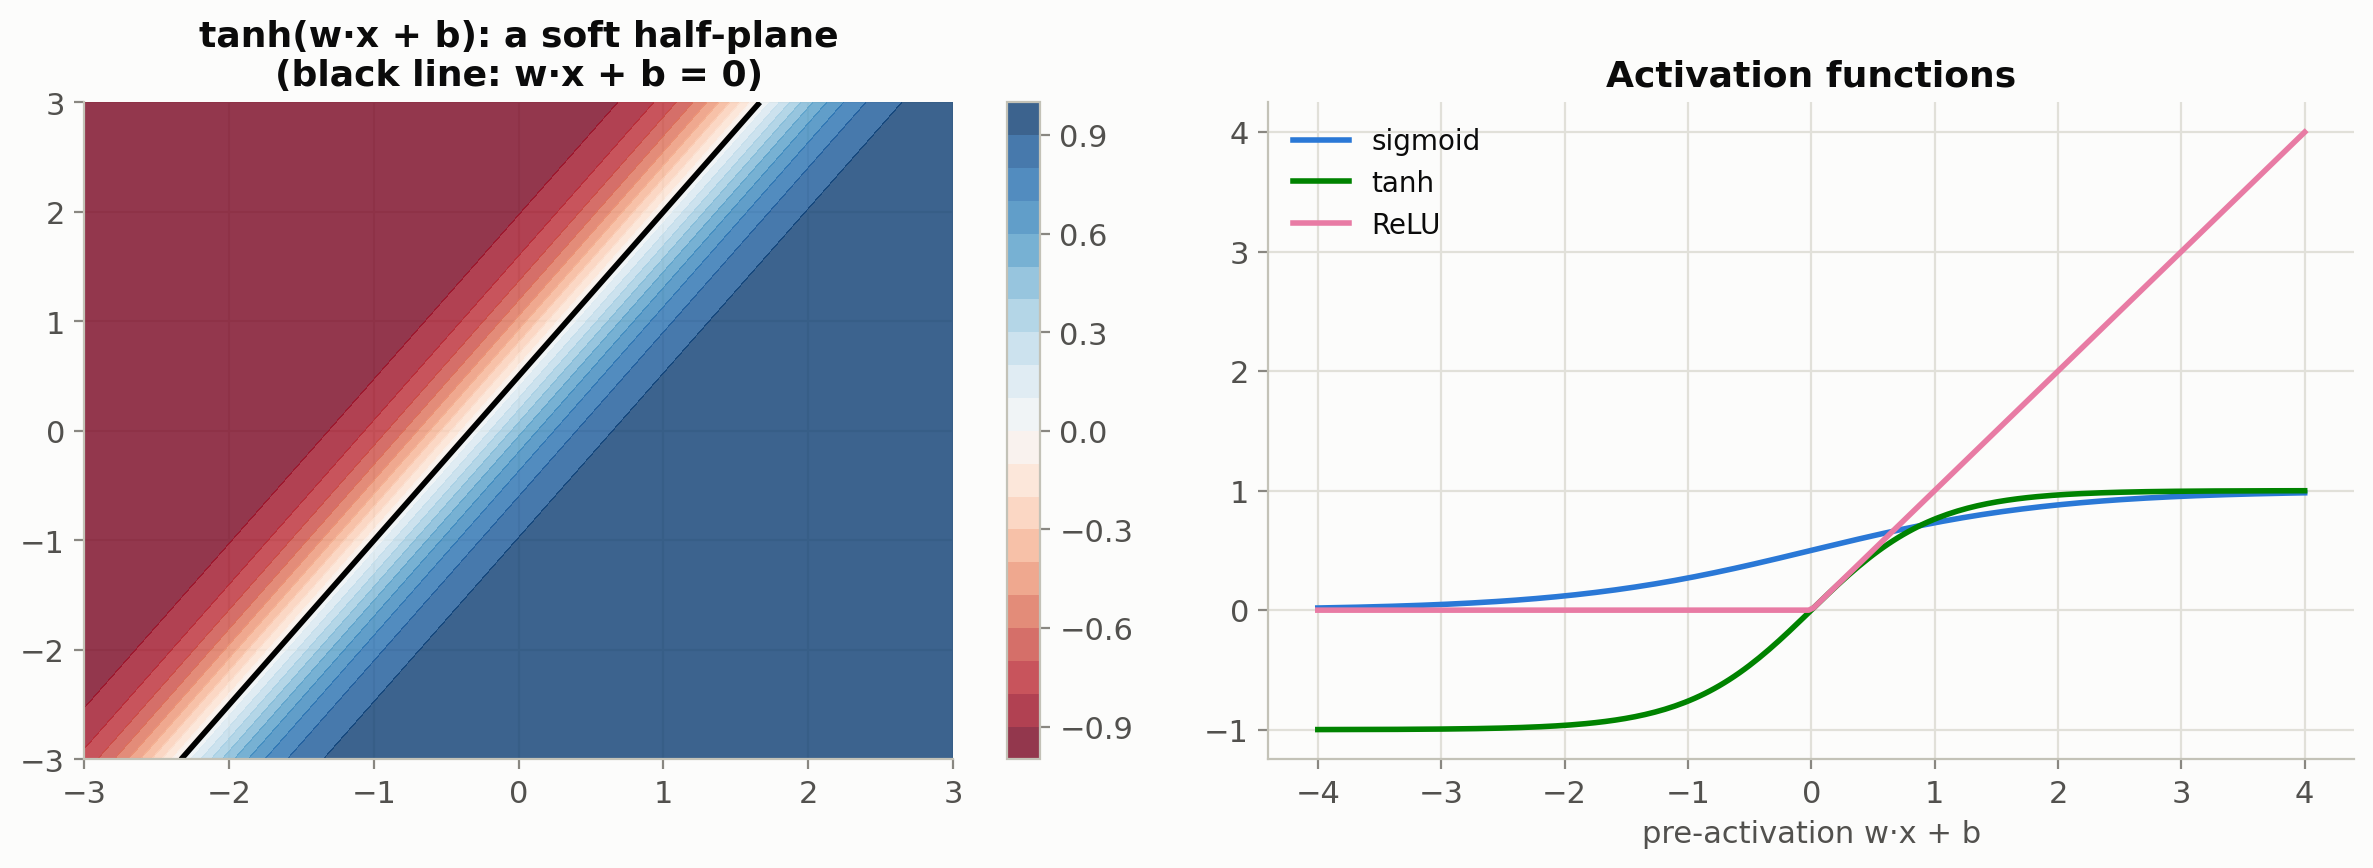

In [4]:
#| code-fold: true
#| code-summary: "Plot: the neuron's half-plane, and three activations"
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: the neuron's view of the plane
gx, gy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.stack([gx.ravel(), gy.ravel()], axis=1)
zz = neuron(grid).reshape(gx.shape)
cf = axes[0].contourf(gx, gy, zz, levels=20, cmap='RdBu', alpha=0.8)
axes[0].contour(gx, gy, zz, levels=[0.0], colors='k', linewidths=2)
fig.colorbar(cf, ax=axes[0])
axes[0].set_title('tanh(w·x + b): a soft half-plane\n(black line: w·x + b = 0)')

# Right: the classic activations
z = np.linspace(-4, 4, 200)
axes[1].plot(z, 1 / (1 + np.exp(-z)), label='sigmoid')
axes[1].plot(z, np.tanh(z), label='tanh')
axes[1].plot(z, np.maximum(0, z), label='ReLU')
axes[1].legend()
axes[1].set_xlabel('pre-activation w·x + b')
axes[1].set_title('Activation functions')
plt.tight_layout()
plt.show()

One neuron = one line. Every decision it can express is "which side of my line are you on,
and by how much". To draw anything curvier, we need to *combine* neurons — and for that,
the nonlinearity is load-bearing.

## 2. Why the nonlinearity is not optional

Stack two **linear** layers (no activation) and you get... one linear layer. The composition
of matrix multiplies is a matrix multiply: `(x @ W1) @ W2 = x @ (W1 @ W2)`. Depth without
nonlinearity buys exactly nothing:

In [5]:
W1 = rng.normal(size=(2, 8))
W2 = rng.normal(size=(8, 1))

x_batch = rng.normal(size=(5, 2))
two_layers = (x_batch @ W1) @ W2       # "deep" linear network
one_layer = x_batch @ (W1 @ W2)        # single equivalent matrix

print('max |two_layers - one_layer| =', np.abs(two_layers - one_layer).max())
print('The 2-8-1 linear net IS the 2-1 matrix W1 @ W2 — still a single line.')

max |two_layers - one_layer| = 8.881784197001252e-16
The 2-8-1 linear net IS the 2-1 matrix W1 @ W2 — still a single line.


## 3. XOR: the smallest problem one neuron cannot solve

XOR's positive examples sit on *opposite* corners — no single line separates them
(Minsky & Papert's 1969 objection to the perceptron). Two tanh neurons plus a combiner do
it: one neuron draws each line, the combiner ANDs the two half-planes. Weights below are
set **by hand** — learning them is the next two chapters.

In [6]:
# Hidden neuron 1: fires above the line x1 + x2 = 0.5   ("at least one input on")
# Hidden neuron 2: fires below the line x1 + x2 = 1.5   ("not both inputs on")
Wh = np.array([[ 4.0,  4.0],
               [-4.0, -4.0]]).T           # (2 inputs, 2 hidden)
bh = np.array([-2.0, 6.0])
wo = np.array([3.0, 3.0])                 # AND the two half-planes
bo = -3.0

def xor_mlp(x):
    h = np.tanh(x @ Wh + bh)              # (n, 2) hidden activations
    return np.tanh(h @ wo + bo)           # (n,) output

X_xor = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
for xi, target in zip(X_xor, [0, 1, 1, 0]):
    print(f'  x = {xi}  →  {xor_mlp(xi[None])[0]:+.2f}   (XOR: {target})')

  x = [0. 0.]  →  -0.99   (XOR: 0)
  x = [0. 1.]  →  +0.99   (XOR: 1)
  x = [1. 0.]  →  +0.99   (XOR: 1)
  x = [1. 1.]  →  -0.99   (XOR: 0)


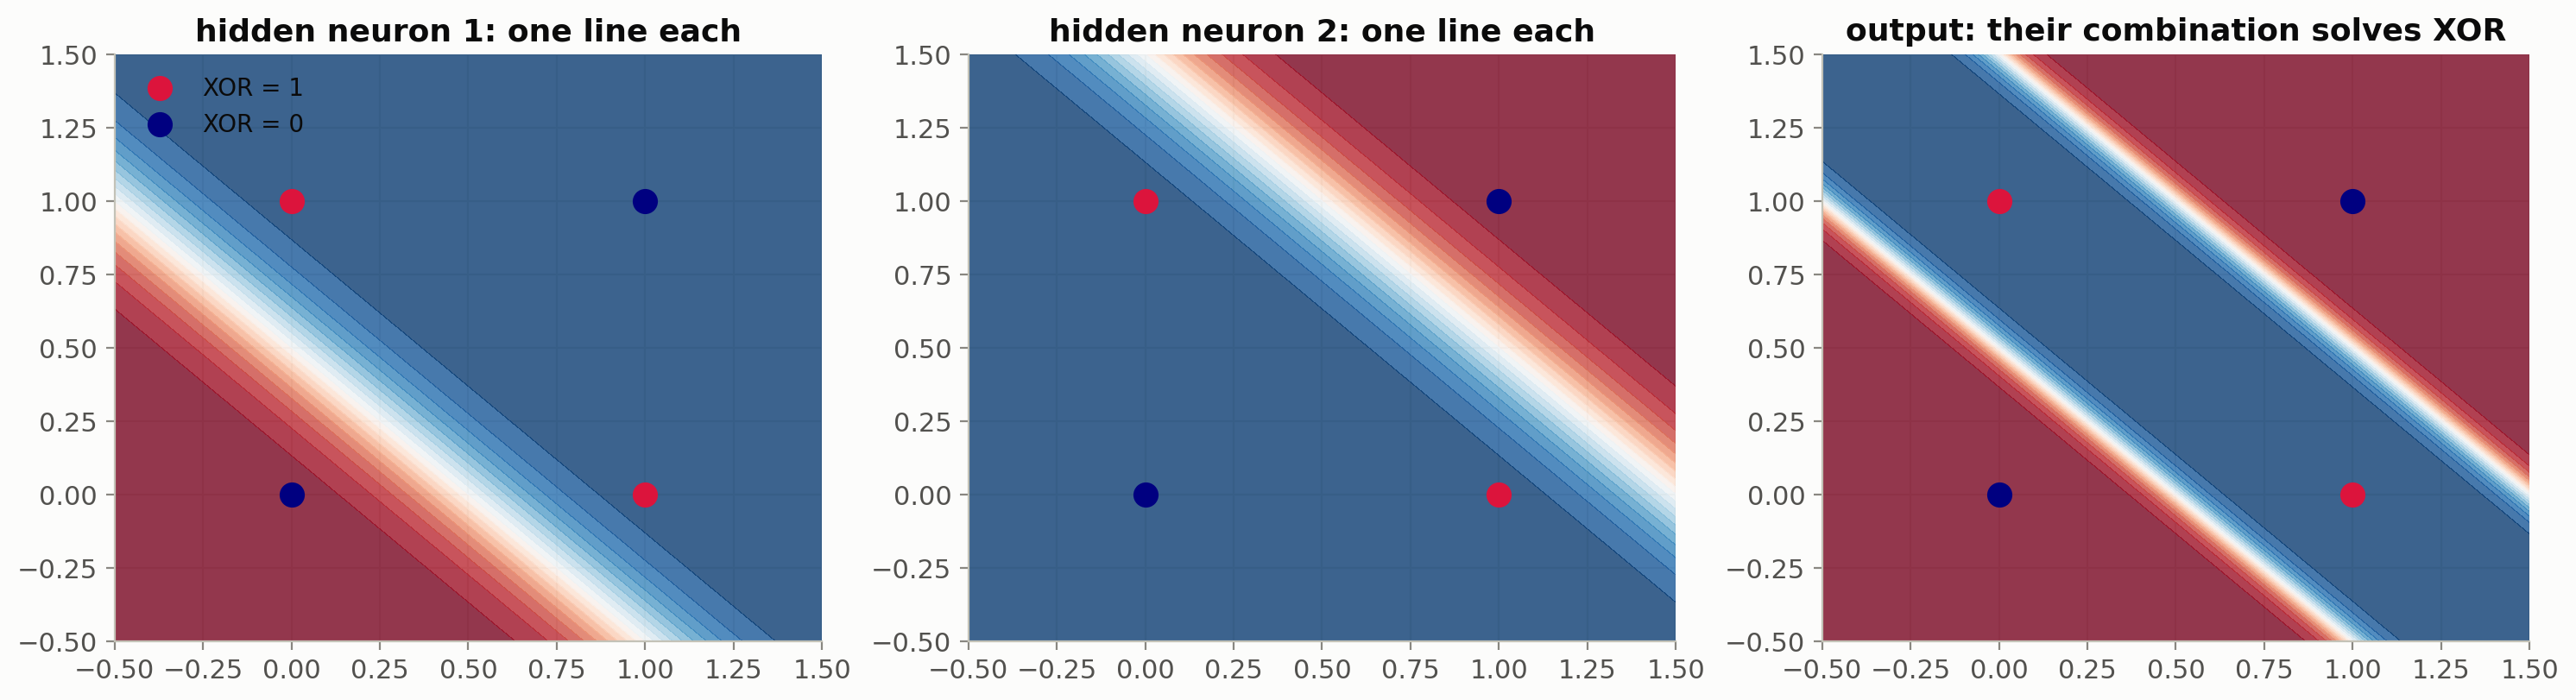

In [7]:
#| code-fold: true
#| code-summary: "Plot: the two hidden half-planes and their combination"
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
gx, gy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.stack([gx.ravel(), gy.ravel()], axis=1)
h = np.tanh(grid @ Wh + bh)

for i, ax in enumerate(axes[:2]):
    ax.contourf(gx, gy, h[:, i].reshape(gx.shape), levels=20, cmap='RdBu', alpha=0.8)
    ax.set_title(f'hidden neuron {i + 1}: one line each')
axes[2].contourf(gx, gy, xor_mlp(grid).reshape(gx.shape), levels=20, cmap='RdBu', alpha=0.8)
axes[2].set_title('output: their combination solves XOR')
for ax in axes:
    ax.scatter([0, 1], [1, 0], c='crimson', s=90, zorder=3, label='XOR = 1')
    ax.scatter([0, 1], [0, 1], c='navy', s=90, zorder=3, label='XOR = 0')
axes[0].legend(loc='upper left')
plt.tight_layout()
plt.show()

## 4. A layer is a matmul

Running each neuron separately is a loop over dot products. Stacking every neuron's `w`
as a **column of a matrix** turns the whole layer — over a whole batch — into one matrix
multiplication. This notation carries the entire book: attention, FFNs, the output head
are all `x @ W` at heart (see it in 3D in the
[Transformer Overview](../01_transformer_internals/00_transformer_overview.ipynb)):

In [8]:
batch = rng.normal(size=(32, 2))          # (batch, n_in)   32 points, 2 features
W = rng.normal(size=(2, 8)) / np.sqrt(2)  # (n_in, n_out)   8 neurons' weights, as columns
b_vec = np.zeros(8)                       # (n_out,)        one bias per neuron

hidden = np.tanh(batch @ W + b_vec)       # (32, 2) @ (2, 8) -> (32, 8)

print(f'input   {batch.shape}   @   W {W.shape}   ->   hidden {hidden.shape}')
print('One matmul = every neuron applied to every example at once.')
print('This is why GPUs (matmul machines) and neural nets get along so well.')

input   (32, 2)   @   W (2, 8)   ->   hidden (32, 8)
One matmul = every neuron applied to every example at once.
This is why GPUs (matmul machines) and neural nets get along so well.


## 5. Depth and width: what random networks already do

An MLP with enough hidden units can approximate any continuous function
([Cybenko, 1989](https://doi.org/10.1007/BF02551274)) — width buys expressiveness, depth
buys it *cheaply* (features composed of features). You can see the raw material even with
**random, untrained weights**: deeper/wider nets carve wigglier regions out of the plane.

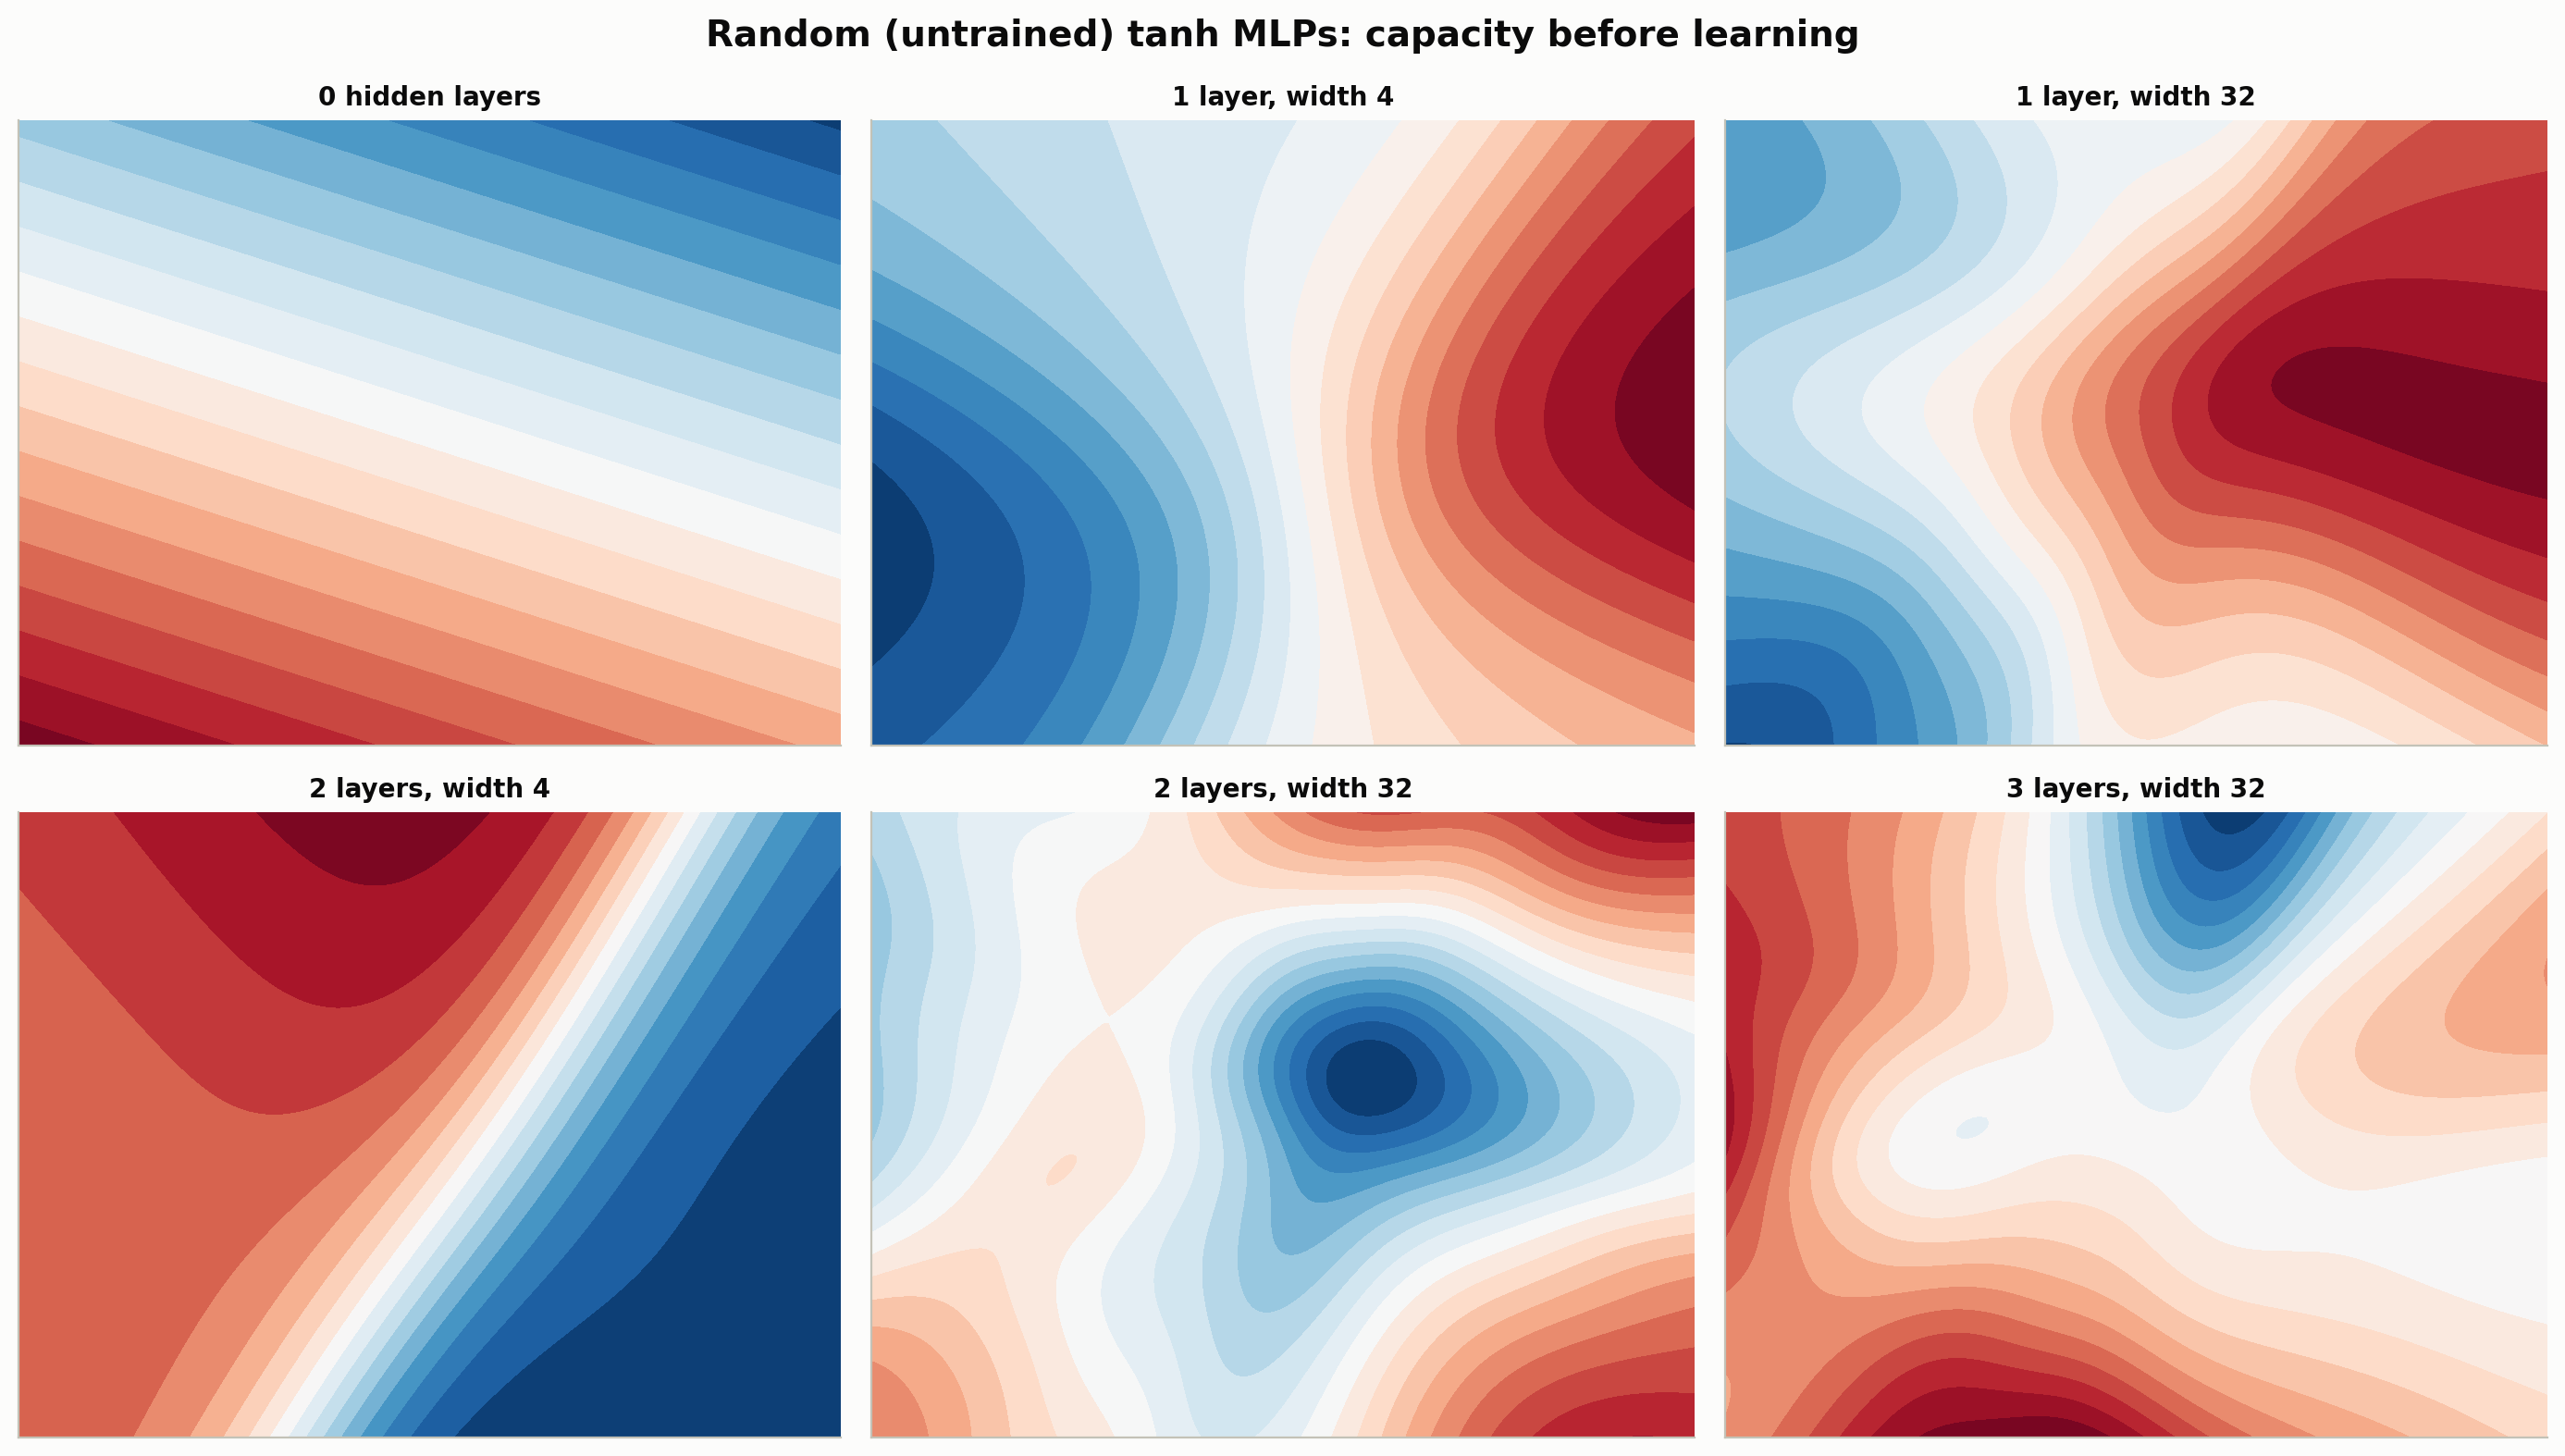

In [9]:
#| code-fold: true
#| code-summary: "Plot: random-weight MLPs of increasing depth and width"
def random_mlp_fn(sizes, seed):
    r = np.random.default_rng(seed)
    mats = [(r.normal(size=(a, b)) / np.sqrt(a), r.normal(size=b))
            for a, b in zip(sizes[:-1], sizes[1:])]
    def f(x):
        h = x
        for i, (Wi, bi) in enumerate(mats):
            h = h @ Wi + bi
            if i < len(mats) - 1:
                h = np.tanh(h)
        return h[:, 0]
    return f

configs = [([2, 1], '0 hidden layers'), ([2, 4, 1], '1 layer, width 4'),
           ([2, 32, 1], '1 layer, width 32'), ([2, 4, 4, 1], '2 layers, width 4'),
           ([2, 32, 32, 1], '2 layers, width 32'), ([2, 32, 32, 32, 1], '3 layers, width 32')]
gx, gy = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
grid = np.stack([gx.ravel(), gy.ravel()], axis=1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (sizes, label) in zip(axes.ravel(), configs):
    zz = random_mlp_fn(sizes, seed=1)(grid).reshape(gx.shape)
    ax.contourf(gx, gy, zz, levels=20, cmap='RdBu')
    ax.set_title(label, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Random (untrained) tanh MLPs: capacity before learning', y=0.98)
plt.tight_layout()
plt.show()

## 6. A real dataset — and the missing ingredient

`ai_playground.fundamentals.datasets.make_moons` gives two interleaved arcs: not linearly
separable, easily solved by a small MLP — *if the weights are right*. With random weights,
the boundary is confidently, uselessly wrong:

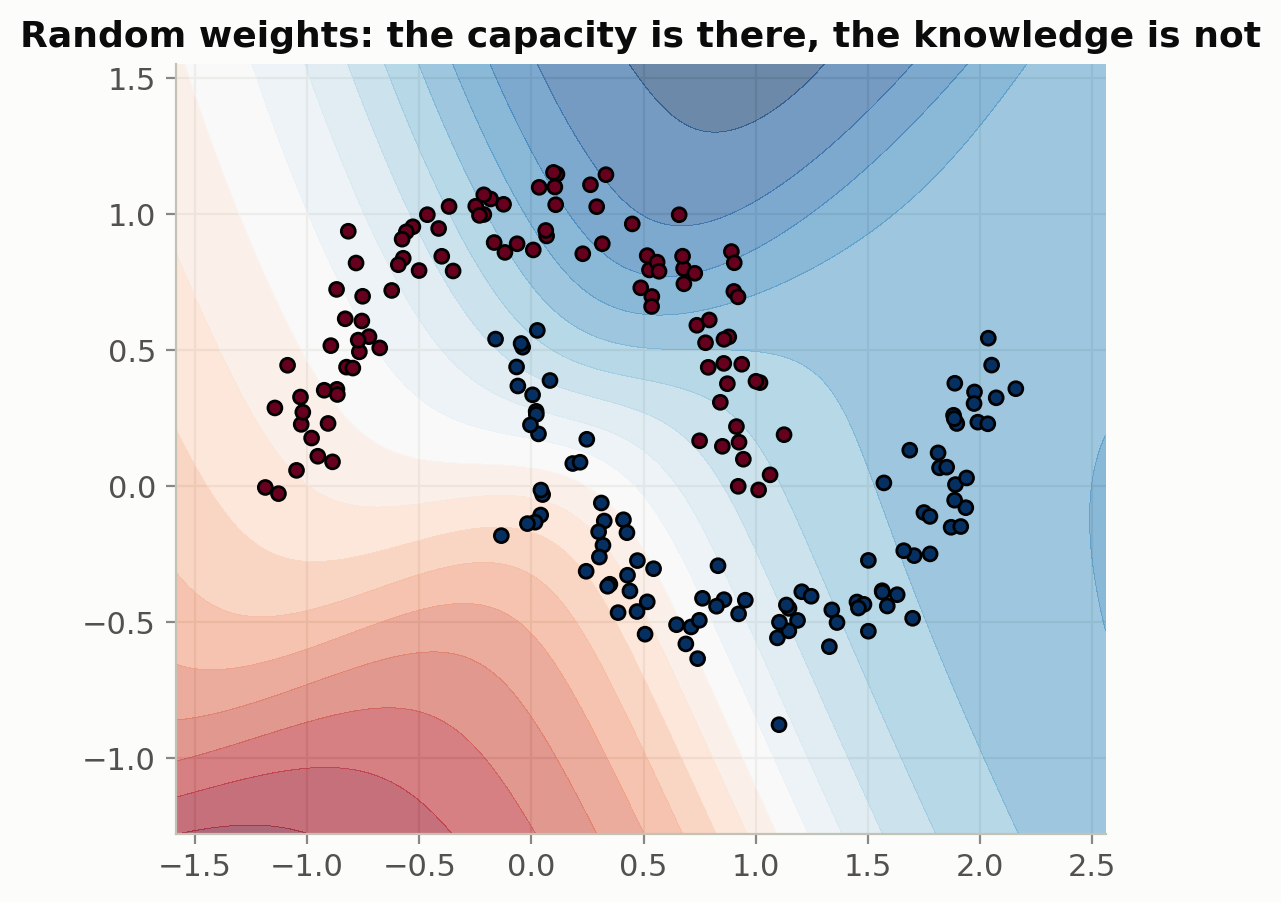

In [10]:
from ai_playground.fundamentals import make_moons, plot_decision_boundary

X, y = make_moons(n=200, noise=0.1, seed=0)
f = random_mlp_fn([2, 8, 1], seed=3)

ax = plot_decision_boundary(f, X, y)
ax.set_title('Random weights: the capacity is there, the knowledge is not')
plt.show()

## Key Takeaways

1. **A neuron is `w·x + b` through a squash** — one line's worth of opinion about the plane.
2. **Nonlinearity is load-bearing**: stacked linear layers collapse to a single matrix
   (`(x@W1)@W2 = x@(W1@W2)`); the activation between them is what makes depth real.
3. **A layer is a matmul** — `(batch, n_in) @ (n_in, n_out)`. All of
   `ai_playground.models` is this pattern at scale.
4. **Capacity ≠ knowledge**: random deep nets carve rich regions
   ([Cybenko, 1989](https://doi.org/10.1007/BF02551274) says rich enough), but the moons
   boundary is garbage until the weights are *learned*.
5. Learning the weights means computing **how the loss changes with each weight** — the
   gradient. Building the machine that computes it is the next chapter:
   [Backprop from Scratch](01_backprop_micrograd.ipynb).